<a href="https://colab.research.google.com/github/epmbanten/Tugas-AI-602225073-Dody-Suhendra/blob/main/PROGRAM_INFERENCE_UNTUK_ENERGY_FORECASTING_(ReLU_VERSION).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Program Inference (ReLU Version) Start
Hello, Dody Suhendra (6022251073) !
The current time is: 2026-06-14 14:03:16

Loading model Energy Forecasting_ReLU.keras...
Model loaded successfully!

Data riwayat terakhir pada dataset berada di tanggal: 2018-08-02 19:00:00
Melakukan peramalan untuk 24 langkah ke depan...


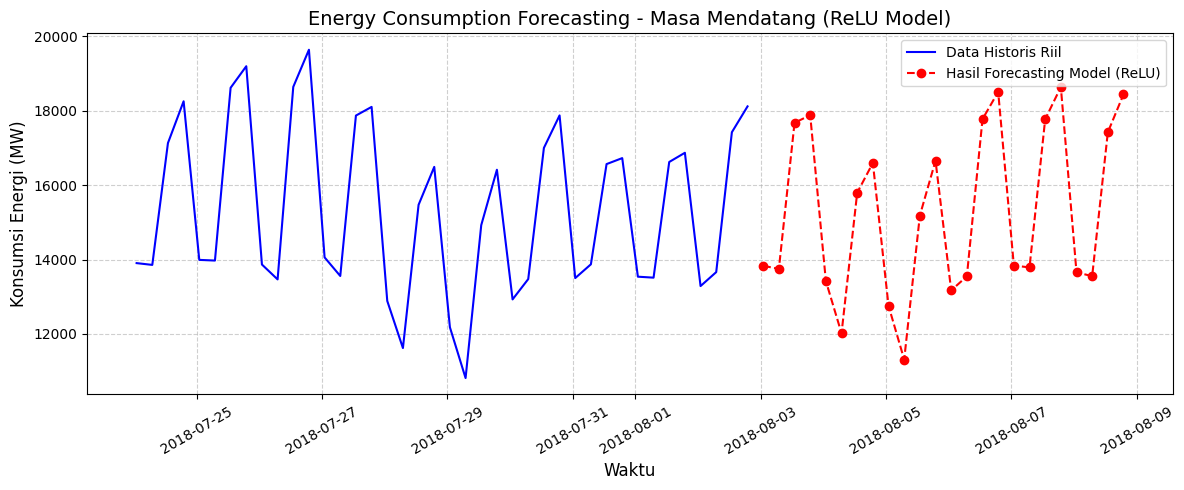


Tabel Hasil Prediksi Energi Masa Depan:
   Waktu Masa Depan  Prediksi Konsumsi (MW)
2018-08-03 01:00:00            13830.414782
2018-08-03 07:00:00            13748.485949
2018-08-03 13:00:00            17675.912585
2018-08-03 19:00:00            17881.953112
2018-08-04 01:00:00            13422.002306
2018-08-04 07:00:00            12015.459948
2018-08-04 13:00:00            15796.594286
2018-08-04 19:00:00            16596.464464
2018-08-05 01:00:00            12754.770495
2018-08-05 07:00:00            11310.281481
2018-08-05 13:00:00            15183.122790
2018-08-05 19:00:00            16656.783800
2018-08-06 01:00:00            13169.373034
2018-08-06 07:00:00            13547.403673
2018-08-06 13:00:00            17774.972643
2018-08-06 19:00:00            18508.754870
2018-08-07 01:00:00            13837.897936
2018-08-07 07:00:00            13787.510851
2018-08-07 13:00:00            17771.216295
2018-08-07 19:00:00            18637.349352
2018-08-08 01:00:00            1365

In [1]:
# =====================================================================
# TUGAS 4 & 5: PROGRAM INFERENCE UNTUK ENERGY FORECASTING (ReLU VERSION)
# Digunakan untuk melakukan peramalan konsumsi energi waktu mendatang
# =====================================================================


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from datetime import datetime, timedelta

print('Program Inference (ReLU Version) Start')

# --- 1. IDENTITAS MAHASISWA ---
student_name = 'Dody Suhendra'
student_id = '6022251073'
current_time = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
print(f'Hello, {student_name} ({student_id}) !')
print(f'The current time is: {current_time}\n')

# --- 2. PERSAPAN DATA & PARAMETER SUB-SAMPLING ---
window_size = 80
data_filename = 'AEP_hourly.csv'

# Load data asli untuk mengambil window terakhir sebagai modal awal
df = pd.read_csv(data_filename)
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values(by='Datetime')
df = df[df['Datetime'] > '2011-12-31 23:00:00']

# Jalankan sub-sampling 6 jam yang sama seperti saat training
df = df[0::6]

# Menghitung kembali nilai Mean dan STD asli dari 80% data training awal
n = len(df)
train_df_original = df[0: int(n * 0.8)]
train_mean = train_df_original['AEP_MW'].mean()
train_std = train_df_original['AEP_MW'].std()

# --- 3. LOAD MODEL REVISI (ReLU VERSION) ---

# Di bagian ini nama file sudah otomatis diubah ke model ReLU kamu
model_filename = 'Energy Forecasting_ReLU.keras'
print(f"Loading model {model_filename}...")
model = tf.keras.models.load_model(model_filename)
print("Model loaded successfully!\n")

# --- 4. MENYIAPKAN INPUT WINDOW TERAKHIR ---

# Mengambil 80 data riwayat terakhir dari dataset
last_window_data = df.tail(window_size).copy()
last_date = last_window_data['Datetime'].max()

print(f"Data riwayat terakhir pada dataset berada di tanggal: {last_date}")

# Ekstrak nilai MW dan normalisasi berdasarkan nilai training Z-score
input_sequence = last_window_data['AEP_MW'].values
input_sequence_scaled = (input_sequence - train_mean) / train_std

# Reshape menjadi format tensor input LSTM: (1, 80, 1)
current_batch = np.reshape(input_sequence_scaled, (1, window_size, 1))


# --- 5. PROSES FORECASTING MASA DEPAN (24 STEPS / LANGKAH) ---

# 24 steps x 6 jam = 144 jam (6 hari ke depan)
future_steps = 24
future_predictions_scaled = []

print(f"Melakukan peramalan untuk {future_steps} langkah ke depan...")
for i in range(future_steps):
    # Prediksi nilai 1 langkah ke depan
    predicted_value = model.predict(current_batch, verbose=0)

    # Ambil nilai skalar hasil prediksi
    pred_scalar = predicted_value[0, 0]
    future_predictions_scaled.append(pred_scalar)

    # Geser jendela input (Sliding Window): buang data terlama, masukkan hasil prediksi terbaru
    new_step = np.reshape(pred_scalar, (1, 1, 1))
    current_batch = np.append(current_batch[:, 1:, :], new_step, axis=1)

# --- 6. DENORMALISASI HASIL PREDIKSI KEMBALI KE SATUAN MEGAWATT (MW) ---
future_predictions = (np.array(future_predictions_scaled) * train_std) + train_mean

# --- 7. MEMBUAT TIMESTAMP SUMBU WAKTU MASA DEPAN (MELOMPAT TIAP 6 JAM) ---
future_dates = [last_date + timedelta(hours=6 * (i + 1)) for i in range(future_steps)]

# --- 8. PLOT HASIL PREDIKSI MASA DEPAN ---
plt.figure(figsize=(12, 5))

# Plot data riwayat riil terakhir (40 data terakhir agar grafik proporsional)
plt.plot(last_window_data['Datetime'].tail(40), last_window_data['AEP_MW'].tail(40), 'b-', label='Data Historis Riil')

# Plot hasil proyeksi masa depan model ReLU
plt.plot(future_dates, future_predictions, 'r--o', label='Hasil Forecasting Model (ReLU)')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Konsumsi Energi (MW)', fontsize=12)
plt.title('Energy Consumption Forecasting - Masa Mendatang (ReLU Model)', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# --- 9. MENAMPILKAN TABEL HASIL PREDIKSI MASA DEPAN ---
print("\nTabel Hasil Prediksi Energi Masa Depan:")
forecast_df = pd.DataFrame({'Waktu Masa Depan': future_dates, 'Prediksi Konsumsi (MW)': future_predictions})
print(forecast_df.to_string(index=False))

print('\nProgram Inference End')